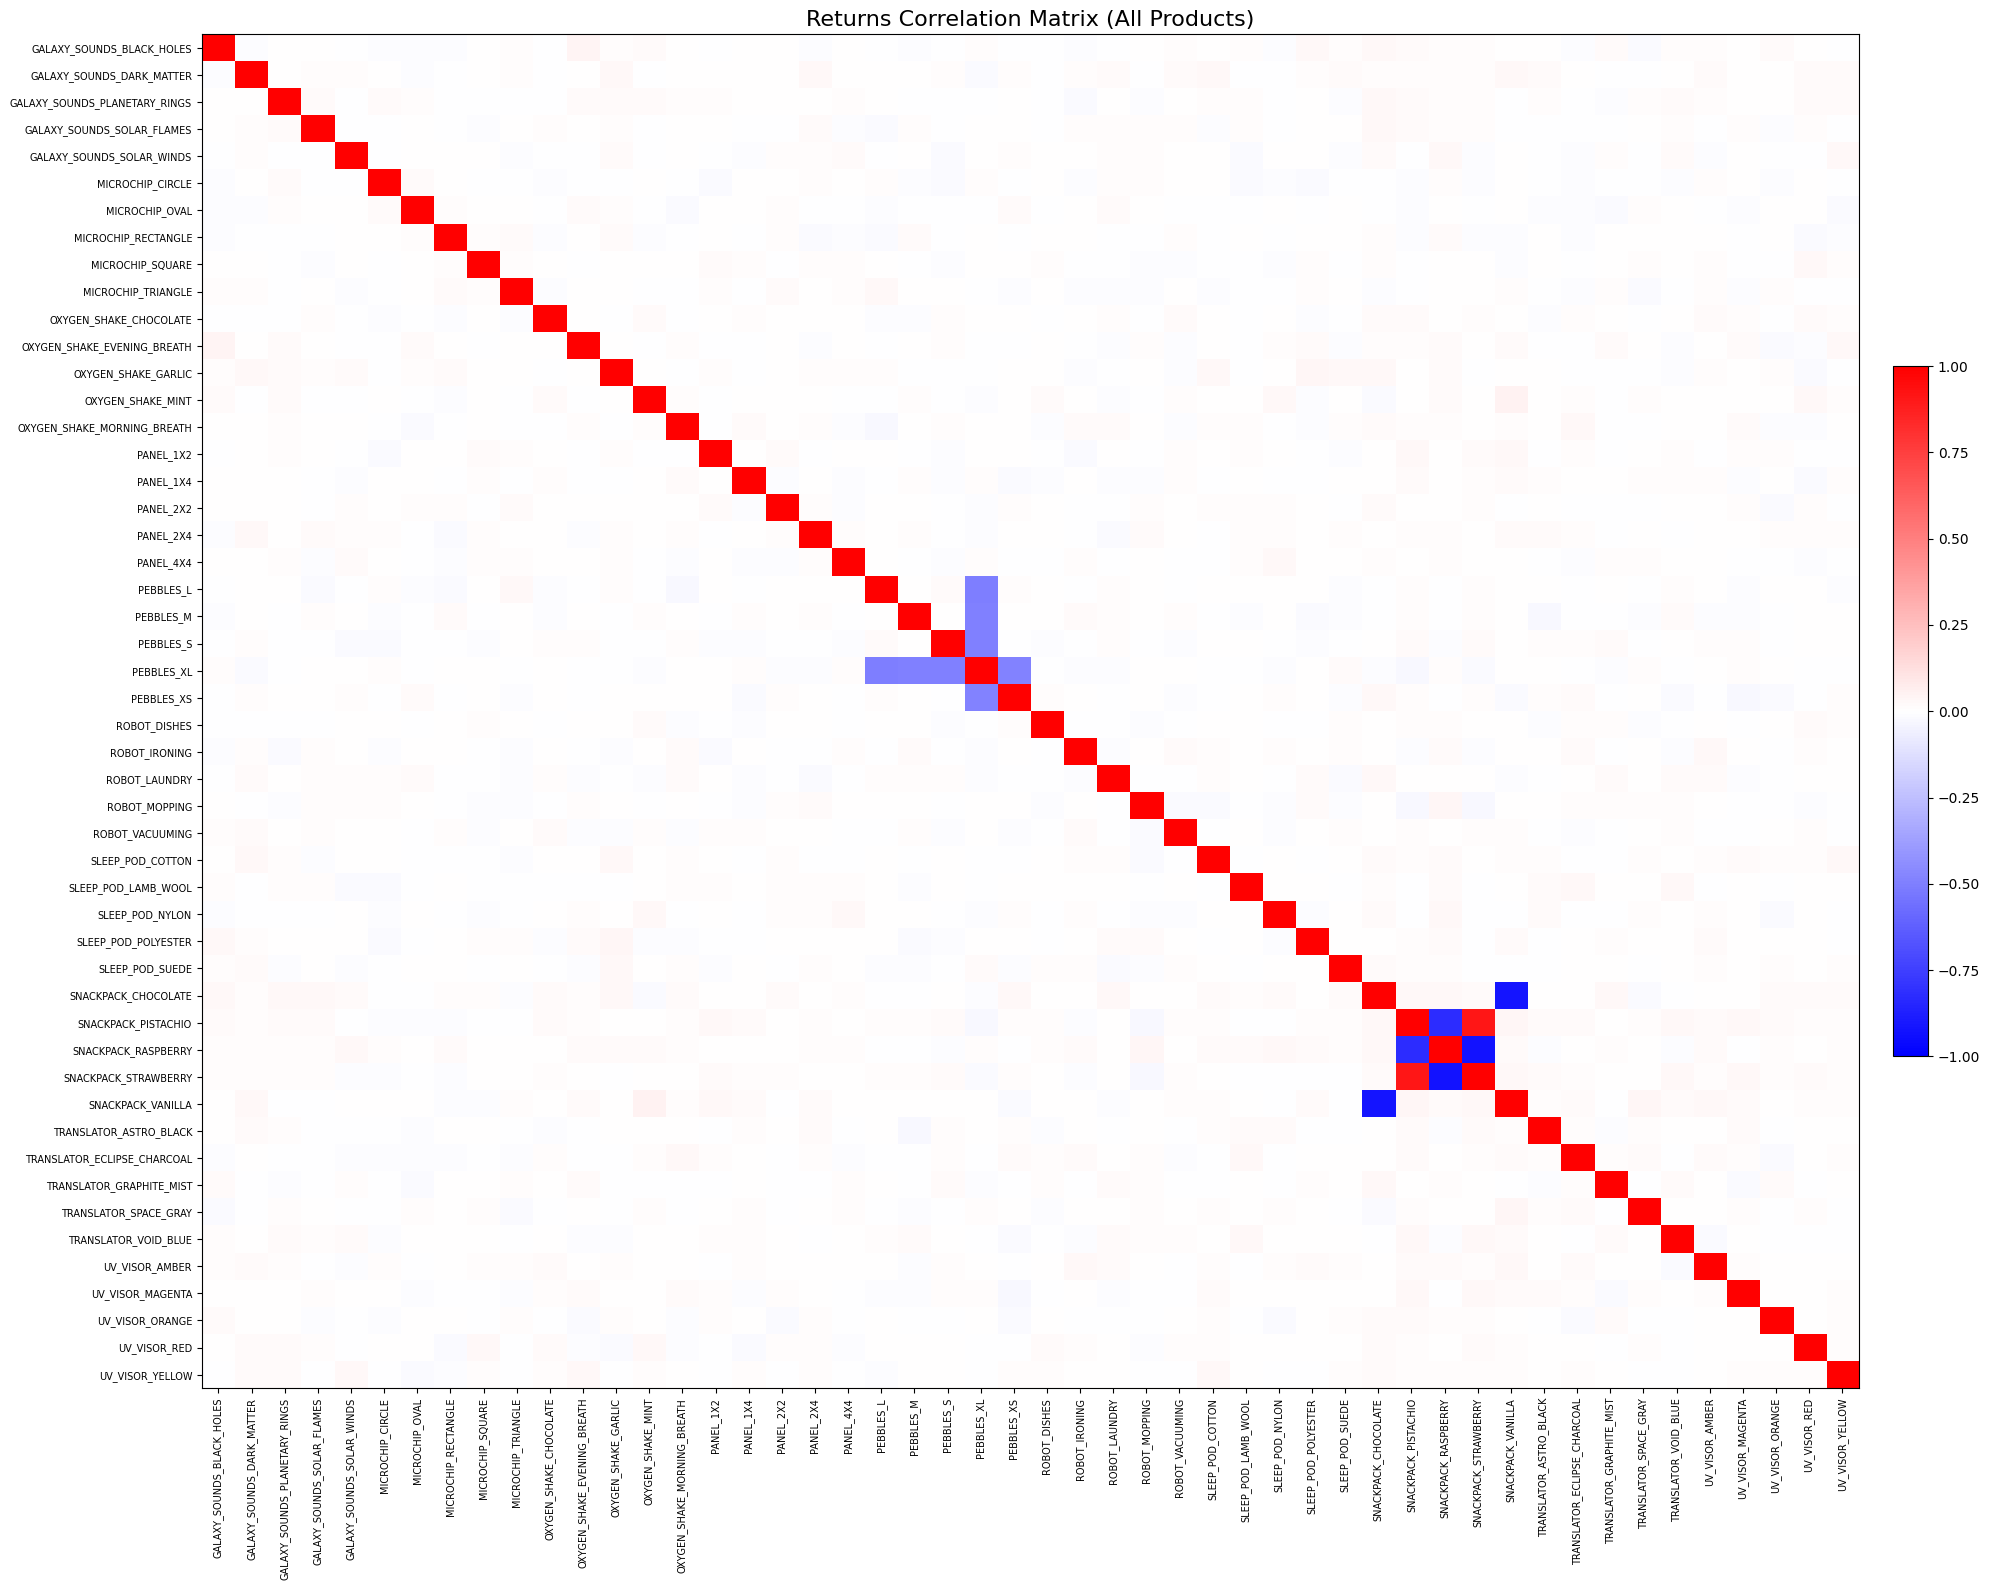


🔥 TOP 25 CORRELATED PAIRS (RETURNS) 🔥

(SNACKPACK_PISTACHIO, SNACKPACK_STRAWBERRY)                   0.910756
(OXYGEN_SHAKE_MINT, SNACKPACK_VANILLA)                        0.049150
(GALAXY_SOUNDS_BLACK_HOLES, OXYGEN_SHAKE_EVENING_BREATH)      0.041005
(ROBOT_MOPPING, SNACKPACK_RASPBERRY)                          0.038545
(SNACKPACK_VANILLA, TRANSLATOR_SPACE_GRAY)                    0.032065
(SNACKPACK_PISTACHIO, SNACKPACK_VANILLA)                      0.031597
(OXYGEN_SHAKE_GARLIC, SLEEP_POD_POLYESTER)                    0.031585
(OXYGEN_SHAKE_GARLIC, SNACKPACK_CHOCOLATE)                    0.031171
(GALAXY_SOUNDS_BLACK_HOLES, SLEEP_POD_POLYESTER)              0.031085
(SNACKPACK_CHOCOLATE, SNACKPACK_PISTACHIO)                    0.030971
(PANEL_4X4, SLEEP_POD_NYLON)                                  0.030571
(GALAXY_SOUNDS_SOLAR_WINDS, UV_VISOR_YELLOW)                  0.030463
(GALAXY_SOUNDS_DARK_MATTER, OXYGEN_SHAKE_GARLIC)              0.030337
(SNACKPACK_CHOCOLATE, SNACKPACK_RASPB

In [5]:
# ─────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ─────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────
price_files = [
    "Data/ROUND_5/prices_round_5_day_2.csv",
    "Data/ROUND_5/prices_round_5_day_3.csv",
    "Data/ROUND_5/prices_round_5_day_4.csv"
]

dfs = []
for file in price_files:
    df = pd.read_csv(file, delimiter=';')
    df['day'] = file.split('_')[-1].replace('.csv', '')
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

# ─────────────────────────────────────────────
# CLEAN DATA
# ─────────────────────────────────────────────
df = df[df['mid_price'] > 0]
df = df.sort_values(['product', 'timestamp'])

# ─────────────────────────────────────────────
# PIVOT
# ─────────────────────────────────────────────
pivot = df.pivot_table(
    index="timestamp",
    columns="product",
    values="mid_price"
)

pivot = pivot.ffill().dropna()

# ─────────────────────────────────────────────
# RETURNS (IMPORTANT)
# ─────────────────────────────────────────────
returns = pivot.pct_change().dropna()

# ─────────────────────────────────────────────
# CORRELATION (RETURNS)
# ─────────────────────────────────────────────
corr = returns.corr()

# ─────────────────────────────────────────────
# HEATMAP (WHITE CENTERED)
# ─────────────────────────────────────────────
cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_rwb",
    ["blue", "white", "red"]
)

norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

plt.figure(figsize=(20, 16))

im = plt.imshow(
    corr,
    cmap=cmap,
    norm=norm,
    aspect='auto'
)

plt.colorbar(im, fraction=0.02, pad=0.02)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=7)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=7)

plt.title("Returns Correlation Matrix (All Products)", fontsize=16)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# TOP CORRELATED PAIRS (CLEAN)
# ─────────────────────────────────────────────
corr_unstacked = corr.unstack()

# remove self correlation
corr_unstacked = corr_unstacked[corr_unstacked < 0.9999]

# remove duplicates (A,B) vs (B,A)
corr_unstacked.index = [
    tuple(sorted(pair)) for pair in corr_unstacked.index
]
corr_unstacked = corr_unstacked[~corr_unstacked.index.duplicated()]

# sort
corr_unstacked = corr_unstacked.sort_values(ascending=False)

print("\n🔥 TOP 25 CORRELATED PAIRS (RETURNS) 🔥\n")
print(corr_unstacked.head(25))

PRICE CORRELATION (>|0.8|)


In [10]:
# ─────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────
price_files = [
    "Data/ROUND_5/prices_round_5_day_2.csv",
    "Data/ROUND_5/prices_round_5_day_3.csv",
    "Data/ROUND_5/prices_round_5_day_4.csv"
]

dfs = []
for file in price_files:
    df_temp = pd.read_csv(file, delimiter=';')
    df_temp['day'] = file.split('_')[-1].replace('.csv', '')
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

# ─────────────────────────────────────────────
# CLEAN
# ─────────────────────────────────────────────
df = df[df['mid_price'] > 0]
df = df.sort_values(['timestamp', 'product'])

# ─────────────────────────────────────────────
# PIVOT
# ─────────────────────────────────────────────
pivot = df.pivot_table(
    index='timestamp',
    columns='product',
    values='mid_price'
)

# forward fill only (no aggressive drop)
pivot = pivot.ffill()

# optional: drop rows where too many missing values
pivot = pivot.dropna(thresh=int(0.9 * pivot.shape[1]))

# ─────────────────────────────────────────────
# PRICE CORRELATION
# ─────────────────────────────────────────────
corr_price = pivot.corr()

# ─────────────────────────────────────────────
# EXTRACT UNIQUE PAIRS
# ─────────────────────────────────────────────
pairs = corr_price.unstack()

# remove self-correlation
pairs = pairs[pairs < 0.9999]

# remove duplicate pairs (A,B) and (B,A)
pairs.index = [tuple(sorted(pair)) for pair in pairs.index]
pairs = pairs[~pairs.index.duplicated()]

# ─────────────────────────────────────────────
# FILTER |CORR| > 0.8
# ─────────────────────────────────────────────
threshold = 0.8

high_corr_price = pairs[abs(pairs) > threshold].sort_values(
    key=lambda x: abs(x),
    ascending=False
)

print(f"\n🔥 PRICE |corr| > {threshold} 🔥\n")
print(high_corr_price)


🔥 PRICE |corr| > 0.8 🔥

(SNACKPACK_CHOCOLATE, SNACKPACK_VANILLA)      -0.973272
(PANEL_2X4, PEBBLES_XS)                       -0.948491
(PEBBLES_XL, PEBBLES_XS)                      -0.947030
(PEBBLES_XL, ROBOT_MOPPING)                    0.936338
(PANEL_2X4, PEBBLES_XL)                        0.935144
                                                 ...   
(PANEL_2X4, PEBBLES_S)                        -0.802004
(OXYGEN_SHAKE_GARLIC, ROBOT_MOPPING)           0.801516
(PEBBLES_XS, TRANSLATOR_GRAPHITE_MIST)         0.801375
(PEBBLES_S, TRANSLATOR_ASTRO_BLACK)            0.801214
(SNACKPACK_CHOCOLATE, TRANSLATOR_VOID_BLUE)   -0.800728
Length: 98, dtype: float64


RETURNS CORRELATION >|0.8|


In [11]:
# ─────────────────────────────────────────────
# RETURNS (PERCENT CHANGE)
# ─────────────────────────────────────────────
returns = pivot.pct_change()

# remove initial NaNs
returns = returns.dropna(how='all')

# optional: drop rows with too many NaNs
returns = returns.dropna(thresh=int(0.9 * returns.shape[1]))

# ─────────────────────────────────────────────
# RETURNS CORRELATION
# ─────────────────────────────────────────────
corr_returns = returns.corr()

# ─────────────────────────────────────────────
# EXTRACT UNIQUE PAIRS
# ─────────────────────────────────────────────
pairs_ret = corr_returns.unstack()

# remove self-correlation
pairs_ret = pairs_ret[pairs_ret < 0.9999]

# remove duplicate pairs
pairs_ret.index = [tuple(sorted(pair)) for pair in pairs_ret.index]
pairs_ret = pairs_ret[~pairs_ret.index.duplicated()]

# ─────────────────────────────────────────────
# FILTER |CORR| > 0.8
# ─────────────────────────────────────────────
threshold = 0.8

high_corr_returns = pairs_ret[abs(pairs_ret) > threshold].sort_values(
    key=lambda x: abs(x),
    ascending=False
)

print(f"\n🔥 RETURNS |corr| > {threshold} 🔥\n")
print(high_corr_returns)


🔥 RETURNS |corr| > 0.8 🔥

(SNACKPACK_RASPBERRY, SNACKPACK_STRAWBERRY)   -0.923075
(SNACKPACK_CHOCOLATE, SNACKPACK_VANILLA)      -0.914769
(SNACKPACK_PISTACHIO, SNACKPACK_STRAWBERRY)    0.910756
(SNACKPACK_PISTACHIO, SNACKPACK_RASPBERRY)    -0.827140
dtype: float64


LEAD-LAG ANALYSIS

In [12]:
# ─────────────────────────────────────────────
# LEAD-LAG ANALYSIS (SNACKPACKS)
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np

# select snackpacks only
snackpacks = [col for col in pivot.columns if "SNACKPACK" in col]

data = pivot[snackpacks]

# compute returns
returns = data.pct_change().dropna()

# max lag to test
max_lag = 10

results = []

for a in snackpacks:
    for b in snackpacks:
        if a == b:
            continue

        for lag in range(1, max_lag + 1):
            # A leads B by lag
            corr = returns[a].corr(returns[b].shift(-lag))

            results.append({
                "leader": a,
                "follower": b,
                "lag": lag,
                "correlation": corr
            })

# convert to dataframe
lag_df = pd.DataFrame(results)

# sort by absolute correlation
lag_df["abs_corr"] = lag_df["correlation"].abs()
lag_df = lag_df.sort_values("abs_corr", ascending=False)

print("\n🔥 TOP LEAD-LAG RELATIONSHIPS 🔥\n")
print(lag_df.head(20))


🔥 TOP LEAD-LAG RELATIONSHIPS 🔥

                   leader              follower  lag  correlation  abs_corr
0     SNACKPACK_CHOCOLATE   SNACKPACK_PISTACHIO    1    -0.023951  0.023951
130  SNACKPACK_STRAWBERRY   SNACKPACK_PISTACHIO    1    -0.023430  0.023430
159  SNACKPACK_STRAWBERRY     SNACKPACK_VANILLA   10     0.021788  0.021788
59    SNACKPACK_PISTACHIO   SNACKPACK_RASPBERRY   10     0.021308  0.021308
149  SNACKPACK_STRAWBERRY   SNACKPACK_RASPBERRY   10     0.020829  0.020829
20    SNACKPACK_CHOCOLATE  SNACKPACK_STRAWBERRY    1    -0.019574  0.019574
67    SNACKPACK_PISTACHIO  SNACKPACK_STRAWBERRY    8     0.019100  0.019100
80    SNACKPACK_RASPBERRY   SNACKPACK_CHOCOLATE    1    -0.018559  0.018559
70    SNACKPACK_PISTACHIO     SNACKPACK_VANILLA    1    -0.018226  0.018226
60    SNACKPACK_PISTACHIO  SNACKPACK_STRAWBERRY    1    -0.018170  0.018170
39    SNACKPACK_CHOCOLATE     SNACKPACK_VANILLA   10    -0.018162  0.018162
137  SNACKPACK_STRAWBERRY   SNACKPACK_PISTACHIO    8   

BASKET VS SINGLE VALIDATION (ALL PRODUCTS)


🔥 BASKET VS SINGLE RANKING 🔥

                          product  autocorr_1  std  zero_crossings      score
37            SNACKPACK_RASPBERRY    0.998215  1.0             222  88.201071
34                SLEEP_POD_SUEDE    0.999469  1.0             171  67.800319
27                  ROBOT_LAUNDRY    0.998800  1.0             169  67.000720
40         TRANSLATOR_ASTRO_BLACK    0.999672  1.0             161  63.800197
1       GALAXY_SOUNDS_DARK_MATTER    0.999010  1.0             150  59.400594
25                   ROBOT_DISHES    0.997760  1.0             146  57.801344
0       GALAXY_SOUNDS_BLACK_HOLES    0.999827  1.0             141  55.800104
22                      PEBBLES_S    0.999615  1.0             139  55.000231
21                      PEBBLES_M    0.999326  1.0             134  53.000404
4       GALAXY_SOUNDS_SOLAR_WINDS    0.999466  1.0             132  52.200321
30               SLEEP_POD_COTTON    0.999419  1.0             129  51.000349
38           SNACKPACK_STRAWBERRY

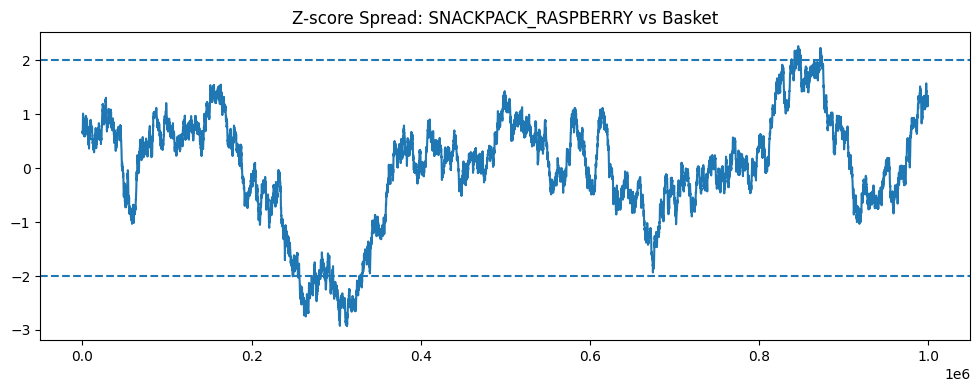

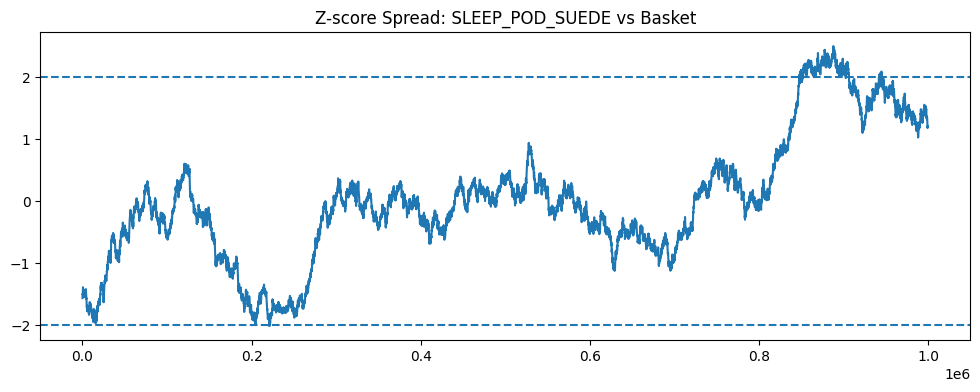

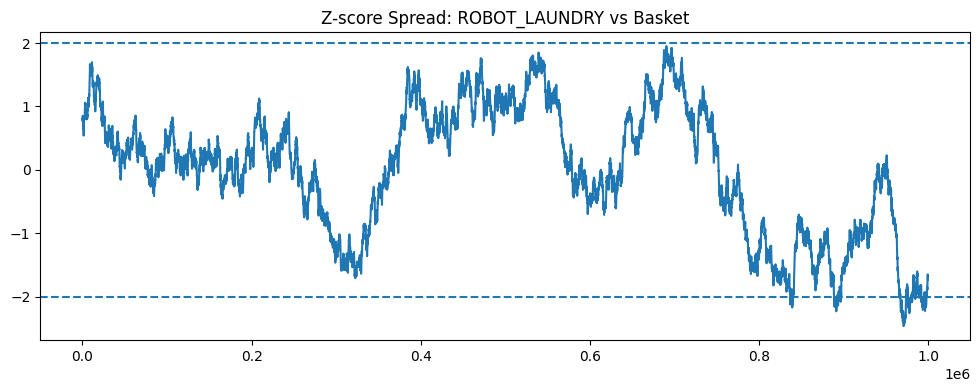

In [13]:
# ─────────────────────────────────────────────
# BASKET VS SINGLE — BRUTE FORCE VALIDATION
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

results = []

products = list(pivot.columns)

for A in products:
    others = [p for p in products if p != A]

    # basket = mean of all others
    basket = pivot[others].mean(axis=1)

    spread = pivot[A] - basket

    # drop NaNs
    spread = spread.dropna()

    # skip if too small
    if len(spread) < 100:
        continue

    # z-score
    z = (spread - spread.mean()) / spread.std()

    # metrics
    autocorr_1 = z.autocorr(lag=1)
    std = z.std()

    # mean reversion proxy: how often it crosses 0
    zero_crossings = ((z.shift(1) * z) < 0).sum()

    results.append({
        "product": A,
        "autocorr_1": autocorr_1,
        "std": std,
        "zero_crossings": zero_crossings
    })

# convert to df
res_df = pd.DataFrame(results)

# ranking logic:
# we WANT:
# - negative autocorr (mean reverting)
# - high zero crossings
res_df["score"] = (
    -res_df["autocorr_1"] * 0.6 +
    res_df["zero_crossings"] * 0.4
)

res_df = res_df.sort_values("score", ascending=False)

print("\n🔥 BASKET VS SINGLE RANKING 🔥\n")
print(res_df.head(20))

# ─────────────────────────────────────────────
# PLOT TOP 3 CANDIDATES
# ─────────────────────────────────────────────

top_n = 3

for A in res_df.head(top_n)["product"]:
    others = [p for p in products if p != A]

    basket = pivot[others].mean(axis=1)
    spread = pivot[A] - basket

    z = (spread - spread.mean()) / spread.std()

    plt.figure(figsize=(12,4))
    plt.plot(z)
    plt.axhline(2, linestyle='--')
    plt.axhline(-2, linestyle='--')
    plt.title(f"Z-score Spread: {A} vs Basket")
    plt.show()

PAIRS TRADING VALIDATION (SNACKPACKS)

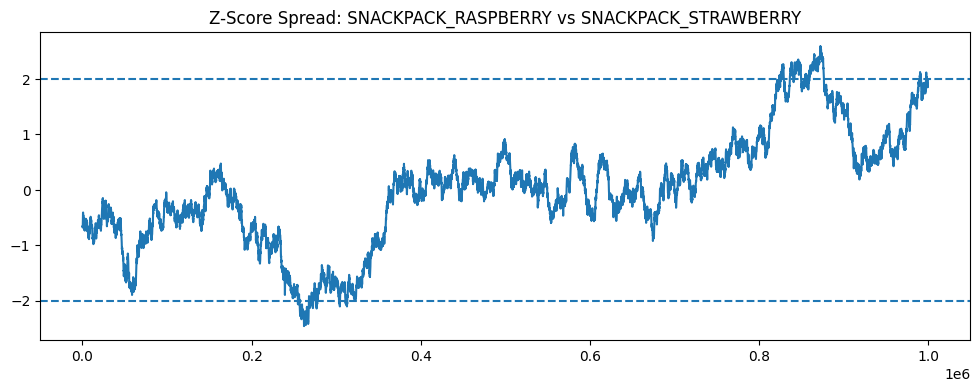

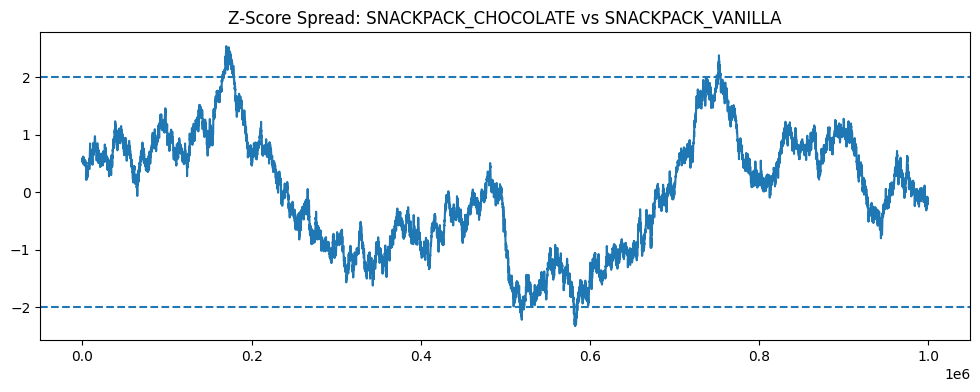

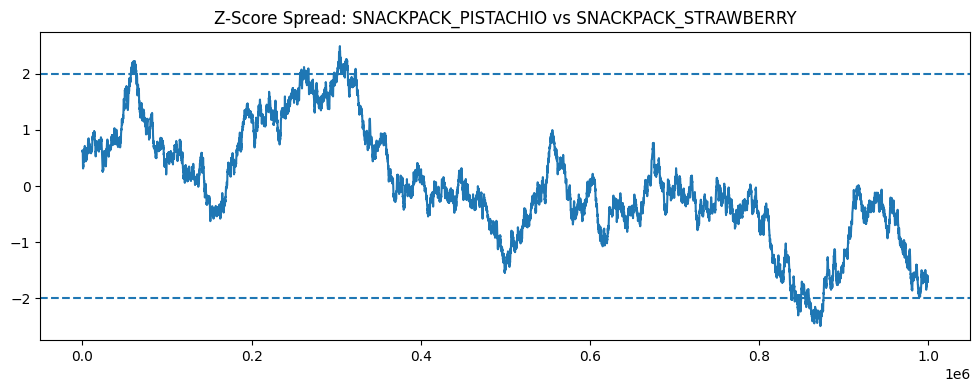

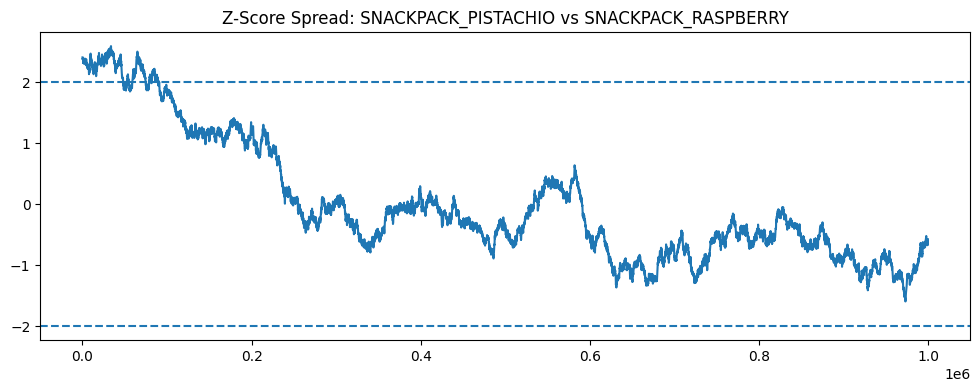


🔥 PAIRS VALIDATION RESULTS 🔥

                                          pair      beta  autocorr_1  \
0  SNACKPACK_RASPBERRY vs SNACKPACK_STRAWBERRY -0.310521    0.998969   
1     SNACKPACK_CHOCOLATE vs SNACKPACK_VANILLA -0.881171    0.997819   
2  SNACKPACK_PISTACHIO vs SNACKPACK_STRAWBERRY -0.277086    0.998958   
3   SNACKPACK_PISTACHIO vs SNACKPACK_RASPBERRY -0.807763    0.999572   

    p_value  zero_crossings  
0  0.645161             193  
1  0.497628             155  
2  0.561770             145  
3  0.362412              93  


In [16]:
# ─────────────────────────────────────────────
# PAIRS TRADING VALIDATION (SNACKPACKS)
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint

# ─────────────────────────────────────────────
# DEFINE PAIRS (FROM YOUR RETURNS FILTER)
# ─────────────────────────────────────────────
pairs = [
    ("SNACKPACK_RASPBERRY", "SNACKPACK_STRAWBERRY"),
    ("SNACKPACK_CHOCOLATE", "SNACKPACK_VANILLA"),
    ("SNACKPACK_PISTACHIO", "SNACKPACK_STRAWBERRY"),
    ("SNACKPACK_PISTACHIO", "SNACKPACK_RASPBERRY"),
]

results = []

# ─────────────────────────────────────────────
# LOOP THROUGH PAIRS
# ─────────────────────────────────────────────
for A, B in pairs:

    series_A = pivot[A]
    series_B = pivot[B]

    # align + drop NaNs
    df_pair = pd.concat([series_A, series_B], axis=1).dropna()
    A_vals = df_pair.iloc[:, 0]
    B_vals = df_pair.iloc[:, 1]

    # ─────────────────────────────────────────
    # HEDGE RATIO (beta via linear regression)
    # ─────────────────────────────────────────
    beta = np.polyfit(B_vals, A_vals, 1)[0]

    # spread
    spread = A_vals - beta * B_vals

    # z-score
    z = (spread - spread.mean()) / spread.std()

    # ─────────────────────────────────────────
    # METRICS
    # ─────────────────────────────────────────
    autocorr_1 = z.autocorr(lag=1)

    # cointegration test
    coint_stat, p_value, _ = coint(A_vals, B_vals)

    # zero crossings (mean reversion proxy)
    zero_crossings = ((z.shift(1) * z) < 0).sum()

    results.append({
        "pair": f"{A} vs {B}",
        "beta": beta,
        "autocorr_1": autocorr_1,
        "p_value": p_value,
        "zero_crossings": zero_crossings
    })

    # ─────────────────────────────────────────
    # PLOT
    # ─────────────────────────────────────────
    plt.figure(figsize=(12,4))
    plt.plot(z)
    plt.axhline(2, linestyle='--')
    plt.axhline(-2, linestyle='--')
    plt.title(f"Z-Score Spread: {A} vs {B}")
    plt.show()

# ─────────────────────────────────────────────
# RESULTS TABLE
# ─────────────────────────────────────────────
res_df = pd.DataFrame(results)

print("\n🔥 PAIRS VALIDATION RESULTS 🔥\n")
print(res_df)

MOMENTUM / TREND VALIDATION

In [17]:
# ─────────────────────────────────────────────
# MOMENTUM / TREND VALIDATION
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np

# focus on snackpacks
snackpacks = [col for col in pivot.columns if "SNACKPACK" in col]

data = pivot[snackpacks]

# compute returns
returns = data.pct_change().dropna()

results = []

# ─────────────────────────────────────────────
# 1. TIME-SERIES MOMENTUM (PER ASSET)
# ─────────────────────────────────────────────
for asset in snackpacks:
    r = returns[asset].dropna()

    # autocorrelation (lag 1)
    autocorr_1 = r.autocorr(lag=1)

    # direction accuracy
    sign_now = np.sign(r)
    sign_next = np.sign(r.shift(-1))

    valid = sign_now.notna() & sign_next.notna()
    accuracy = (sign_now[valid] == sign_next[valid]).mean()

    results.append({
        "asset": asset,
        "autocorr_1": autocorr_1,
        "direction_accuracy": accuracy
    })

ts_df = pd.DataFrame(results)

print("\n🔥 TIME-SERIES MOMENTUM 🔥\n")
print(ts_df)

# ─────────────────────────────────────────────
# 2. CROSS-SECTIONAL MOMENTUM
# ─────────────────────────────────────────────

# compute rolling returns (short window)
window = 20  # you can try 10, 20, 50
rolling_returns = returns.rolling(window).sum()

# rank assets at each timestamp
ranks = rolling_returns.rank(axis=1)

# check persistence of ranking
rank_corrs = []

for t in range(len(ranks) - 1):
    r1 = ranks.iloc[t]
    r2 = ranks.iloc[t+1]

    if r1.isna().any() or r2.isna().any():
        continue

    corr = r1.corr(r2)
    rank_corrs.append(corr)

avg_rank_corr = np.mean(rank_corrs)

print("\n🔥 CROSS-SECTIONAL MOMENTUM 🔥\n")
print(f"Average rank correlation (t vs t+1): {avg_rank_corr:.4f}")


🔥 TIME-SERIES MOMENTUM 🔥

                  asset  autocorr_1  direction_accuracy
0   SNACKPACK_CHOCOLATE   -0.025815            0.470994
1   SNACKPACK_PISTACHIO   -0.031944            0.469594
2   SNACKPACK_RASPBERRY   -0.017974            0.469994
3  SNACKPACK_STRAWBERRY   -0.014660            0.475795
4     SNACKPACK_VANILLA   -0.016020            0.482997

🔥 CROSS-SECTIONAL MOMENTUM 🔥

Average rank correlation (t vs t+1): 0.8541


CROSS-SECTIONAL MOMENTUM BACKTEST


🔥 BACKTEST RESULTS 🔥

Mean Return: -0.000001
Std Dev   : 0.000284
Sharpe    : -2.03


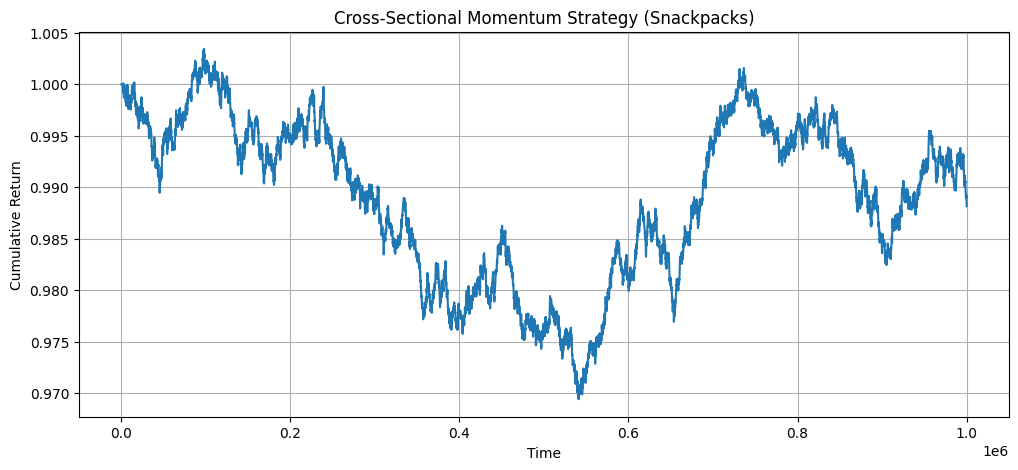

In [18]:
# ─────────────────────────────────────────────
# CROSS-SECTIONAL MOMENTUM BACKTEST
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# SETUP
# ─────────────────────────────────────────────

snackpacks = [col for col in pivot.columns if "SNACKPACK" in col]
data = pivot[snackpacks]

# returns
returns = data.pct_change().dropna()

# rolling window for ranking
window = 20  # try 10, 20, 50 later

# how many to long/short
k = 2

# ─────────────────────────────────────────────
# SIGNAL GENERATION
# ─────────────────────────────────────────────

# rolling cumulative returns
rolling_returns = returns.rolling(window).sum()

# ranks (higher return = stronger)
ranks = rolling_returns.rank(axis=1)

# create signals
signals = pd.DataFrame(0, index=returns.index, columns=returns.columns)

for t in range(len(ranks)):
    row = ranks.iloc[t]

    if row.isna().any():
        continue

    # top k (long)
    long_assets = row.nlargest(k).index

    # bottom k (short)
    short_assets = row.nsmallest(k).index

    signals.loc[ranks.index[t], long_assets] = 1
    signals.loc[ranks.index[t], short_assets] = -1

# ─────────────────────────────────────────────
# NORMALISE POSITIONS
# ─────────────────────────────────────────────

# equal weight long/short
signals = signals.div(signals.abs().sum(axis=1), axis=0)

# shift signals (NO LOOKAHEAD BIAS)
signals = signals.shift(1).fillna(0)

# ─────────────────────────────────────────────
# PNL CALCULATION
# ─────────────────────────────────────────────

pnl = (signals * returns).sum(axis=1)

cum_pnl = (1 + pnl).cumprod()

# ─────────────────────────────────────────────
# METRICS
# ─────────────────────────────────────────────

mean_return = pnl.mean()
std_return = pnl.std()
sharpe = mean_return / std_return * np.sqrt(252 * 1000)  # scaled (approx)

print("\n🔥 BACKTEST RESULTS 🔥\n")
print(f"Mean Return: {mean_return:.6f}")
print(f"Std Dev   : {std_return:.6f}")
print(f"Sharpe    : {sharpe:.2f}")

# ─────────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────────

plt.figure(figsize=(12,5))
plt.plot(cum_pnl)
plt.title("Cross-Sectional Momentum Strategy (Snackpacks)")
plt.xlabel("Time")
plt.ylabel("Cumulative Return")
plt.grid()
plt.show()

FACTOR / RESIDUAL TRADING VALIDATION


🔥 RESIDUAL MEAN REVERSION RESULTS 🔥

                  asset  autocorr_1  zero_crossings      score
2   SNACKPACK_RASPBERRY    0.998286             250  74.301200
3  SNACKPACK_STRAWBERRY    0.999246             111  32.600528
0   SNACKPACK_CHOCOLATE    0.999378              79  23.000436
1   SNACKPACK_PISTACHIO    0.999718              67  19.400198
4     SNACKPACK_VANILLA    0.999378              53  15.200435


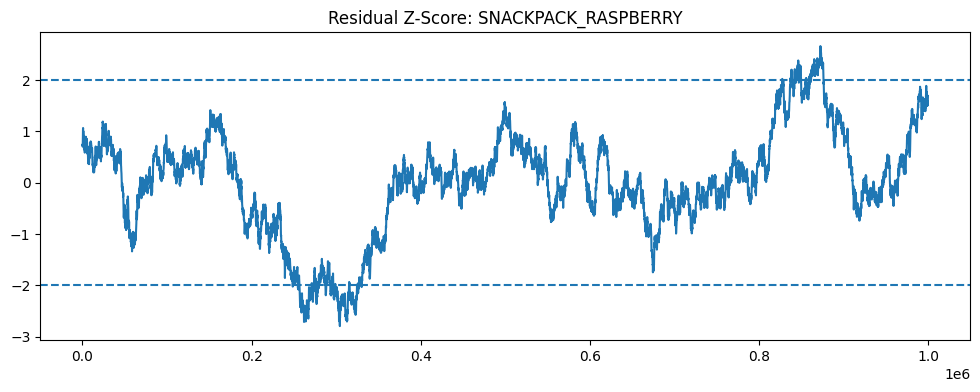

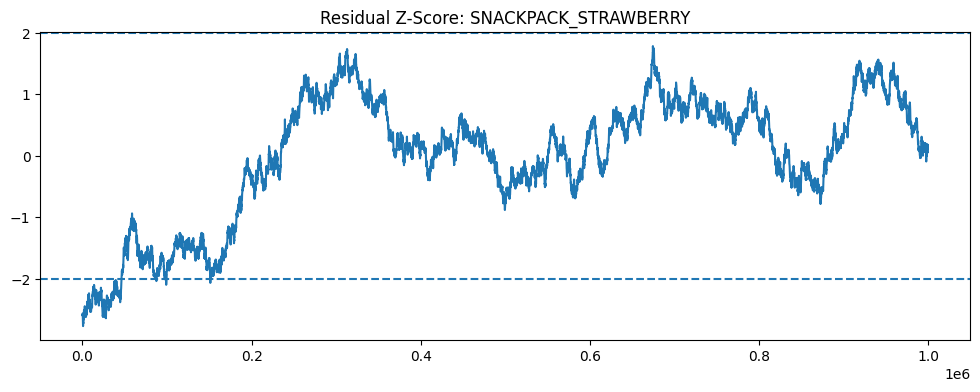

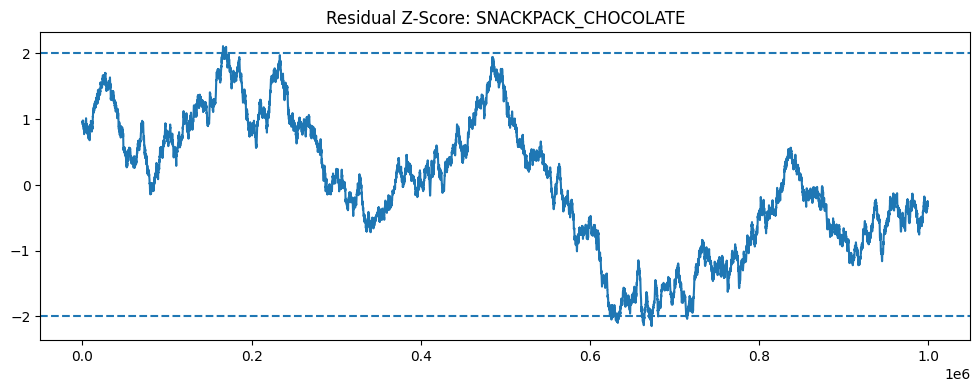

In [19]:
# ─────────────────────────────────────────────
# FACTOR / RESIDUAL VALIDATION (SNACKPACKS)
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# SETUP
# ─────────────────────────────────────────────

snackpacks = [col for col in pivot.columns if "SNACKPACK" in col]
data = pivot[snackpacks]

# ─────────────────────────────────────────────
# STEP 1: BUILD FACTOR (SIMPLE VERSION)
# ─────────────────────────────────────────────

factor = data.mean(axis=1)

# ─────────────────────────────────────────────
# STEP 2: COMPUTE RESIDUALS
# ─────────────────────────────────────────────

residuals = data.sub(factor, axis=0)

# ─────────────────────────────────────────────
# STEP 3: TEST MEAN REVERSION
# ─────────────────────────────────────────────

results = []

for asset in snackpacks:
    r = residuals[asset].dropna()

    # z-score
    z = (r - r.mean()) / r.std()

    # autocorrelation
    autocorr_1 = z.autocorr(lag=1)

    # zero crossings (mean reversion proxy)
    zero_crossings = ((z.shift(1) * z) < 0).sum()

    results.append({
        "asset": asset,
        "autocorr_1": autocorr_1,
        "zero_crossings": zero_crossings
    })

res_df = pd.DataFrame(results)

# rank by MOST mean-reverting:
# want low/negative autocorr + high crossings
res_df["score"] = (-res_df["autocorr_1"] * 0.7 + res_df["zero_crossings"] * 0.3)

res_df = res_df.sort_values("score", ascending=False)

print("\n🔥 RESIDUAL MEAN REVERSION RESULTS 🔥\n")
print(res_df)

# ─────────────────────────────────────────────
# STEP 4: PLOT TOP CANDIDATES
# ─────────────────────────────────────────────

top_n = 3

for asset in res_df.head(top_n)["asset"]:
    r = residuals[asset]
    z = (r - r.mean()) / r.std()

    plt.figure(figsize=(12,4))
    plt.plot(z)
    plt.axhline(2, linestyle='--')
    plt.axhline(-2, linestyle='--')
    plt.title(f"Residual Z-Score: {asset}")
    plt.show()

LOW-FREQUENCY RELATIVE MOMENTUM


🔥 LOW-FREQ MOMENTUM RESULTS 🔥

Mean Return: -0.000003
Std Dev   : 0.000258
Sharpe    : -5.32


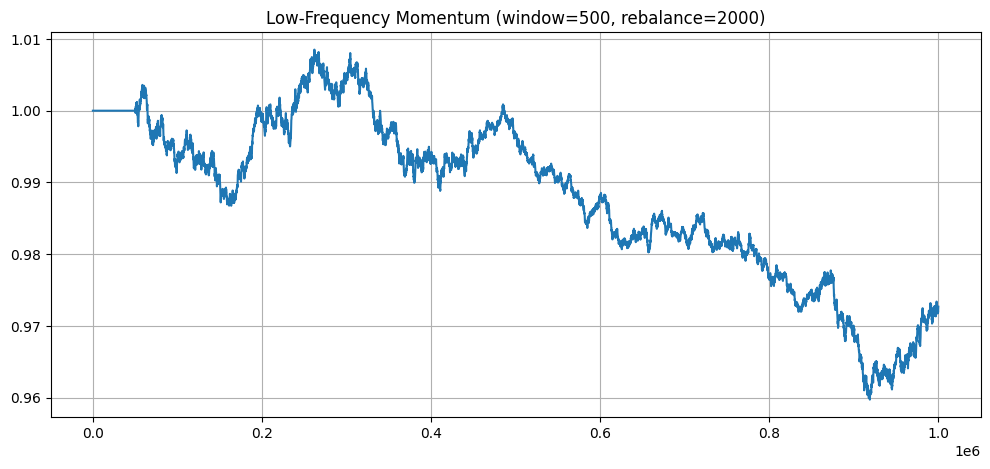

In [20]:
# ─────────────────────────────────────────────
# LOW-FREQUENCY CROSS-SECTIONAL MOMENTUM
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# SETUP
# ─────────────────────────────────────────────

snackpacks = [col for col in pivot.columns if "SNACKPACK" in col]
data = pivot[snackpacks]

returns = data.pct_change().fillna(0)

# parameters (WE WILL TUNE THESE)
signal_window = 500      # how far back to rank (slow signal)
rebalance_freq = 2000    # how often to rebalance
k = 2                    # long top k, short bottom k

# ─────────────────────────────────────────────
# SIGNAL (SLOW MOMENTUM)
# ─────────────────────────────────────────────

# cumulative return over window
signal = data.pct_change(signal_window)

# positions matrix
positions = pd.DataFrame(0, index=data.index, columns=data.columns)

# ─────────────────────────────────────────────
# REBALANCING LOOP
# ─────────────────────────────────────────────

for t in range(signal_window, len(data), rebalance_freq):

    row = signal.iloc[t]

    if row.isna().any():
        continue

    # rank assets
    long_assets = row.nlargest(k).index
    short_assets = row.nsmallest(k).index

    # hold until next rebalance
    end_t = min(t + rebalance_freq, len(data))

    positions.loc[data.index[t:end_t], long_assets] = 1
    positions.loc[data.index[t:end_t], short_assets] = -1

# ─────────────────────────────────────────────
# NORMALISE POSITIONS
# ─────────────────────────────────────────────

positions = positions.div(positions.abs().sum(axis=1), axis=0).fillna(0)

# ─────────────────────────────────────────────
# PNL
# ─────────────────────────────────────────────

pnl = (positions.shift(1) * returns).sum(axis=1)
cum_pnl = (1 + pnl).cumprod()

# ─────────────────────────────────────────────
# METRICS
# ─────────────────────────────────────────────

mean_return = pnl.mean()
std_return = pnl.std()
sharpe = mean_return / std_return * np.sqrt(252 * 1000)

print("\n🔥 LOW-FREQ MOMENTUM RESULTS 🔥\n")
print(f"Mean Return: {mean_return:.6f}")
print(f"Std Dev   : {std_return:.6f}")
print(f"Sharpe    : {sharpe:.2f}")

# ─────────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────────

plt.figure(figsize=(12,5))
plt.plot(cum_pnl)
plt.title(f"Low-Frequency Momentum (window={signal_window}, rebalance={rebalance_freq})")
plt.grid()
plt.show()